
Running precise yielding analysis...
Theoretical yield load per member: 13268.5 kN
Member 9 (N10-N11) yielded at LF=1.540 (Force=13151.4 kN)
Member 8 (N9-N10) yielded at LF=1.545 (Force=13250.2 kN)
Member 10 (N11-N12) yielded at LF=1.612 (Force=13145.0 kN)
Member 11 (N12-N13) yielded at LF=1.620 (Force=13139.9 kN)
Member 1 (N1-N2) yielded at LF=1.646 (Force=-13156.5 kN)
Member 2 (N2-N3) yielded at LF=1.646 (Force=-13161.3 kN)
Reducing increment at LF=1.85
Minimum increment reached - stopping

=== Yield Sequence ===
1. Member 9 (N10-N11): LF=1.540, Force=13151.4 kN
2. Member 8 (N9-N10): LF=1.545, Force=13250.2 kN
3. Member 10 (N11-N12): LF=1.612, Force=13145.0 kN
4. Member 11 (N12-N13): LF=1.620, Force=13139.9 kN
5. Member 1 (N1-N2): LF=1.646, Force=-13156.5 kN
6. Member 2 (N2-N3): LF=1.646, Force=-13161.3 kN


after: 100 iterations  current Norm: 37.619 (max: 1e-06, Norm deltaR: 2.27468e+08)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 1.849
OpenSees > analyze failed, returned: -3 error flag


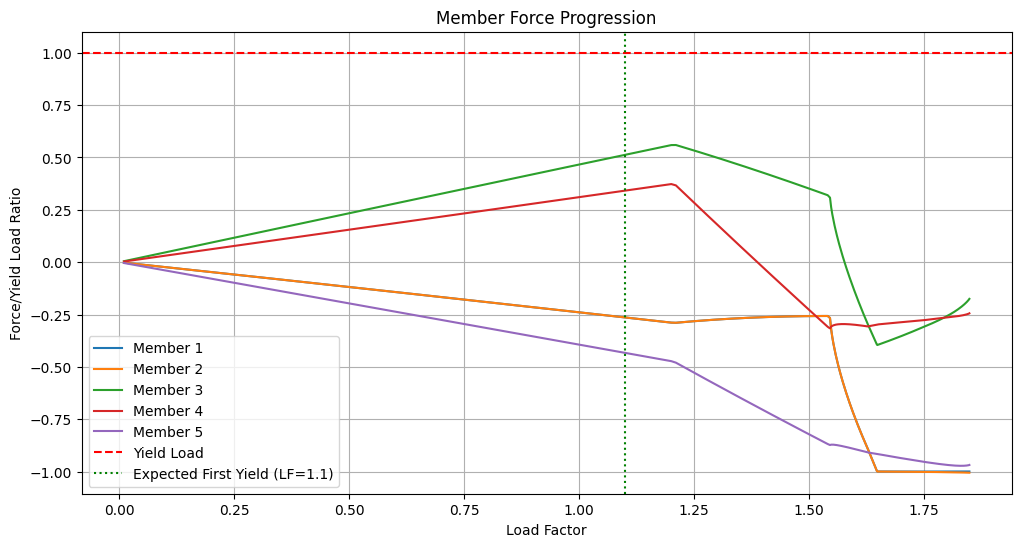

Analysis After Implementing Proposed Suggestion

Running progressive yielding analysis...
Member 5 (N5-N6) yielded at LF=2.56 (Force=12892.7 kN)
Member 11 (N12-N13) yielded at LF=2.60 (Force=12978.2 kN)
Member 28 (N4-N10) yielded at LF=2.76 (Force=12626.9 kN)
Member 29 (N4-N12) yielded at LF=2.76 (Force=12621.2 kN)

=== Yield Progression Summary ===
First yield occurred at LF = 2.56
Collapse occurred at LF ≈ 3.00

Yield Sequence:
1. Member 5 (N5-N6): LF=2.56, Force=12892.7 kN
2. Member 11 (N12-N13): LF=2.60, Force=12978.2 kN
3. Member 28 (N4-N10): LF=2.76, Force=12626.9 kN
4. Member 29 (N4-N12): LF=2.76, Force=12621.2 kN


CTestNormDispIncr::test() - iteration: 2 current Norm: 4.95328e-08 (max: 1e-05, Norm deltaR: 4.61461e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.95445e-08 (max: 1e-05, Norm deltaR: 5.50601e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.95563e-08 (max: 1e-05, Norm deltaR: 3.92928e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.95681e-08 (max: 1e-05, Norm deltaR: 4.13759e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.95799e-08 (max: 1e-05, Norm deltaR: 4.86076e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.95916e-08 (max: 1e-05, Norm deltaR: 4.98481e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.96034e-08 (max: 1e-05, Norm deltaR: 4.31292e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.96152e-08 (max: 1e-05, Norm deltaR: 5.00776e-06)
CTestNormDispIncr::test() - iteration: 2 current Norm: 4.9627e-08 (max: 1e-05, Norm deltaR: 4.11445e-06)
CTestNormDispIncr::test() - iteration: 2 curren

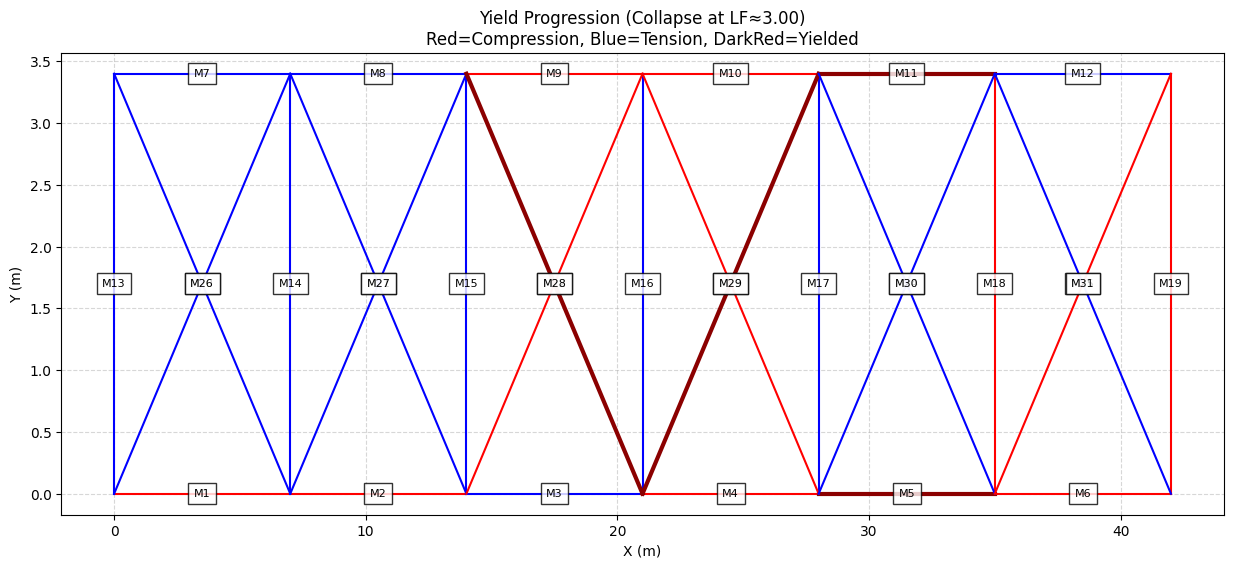

In [51]:
# ========== PRECISE YIELDING ANALYSIS ==========
def run_precise_yielding_analysis():
    print("\nRunning precise yielding analysis...")
    
    # Define members first
    members = [
        (1,2),(2,3),(3,4),(4,5),(5,6),(6,7),        # Bottom chords
        (8,9),(9,10),(10,11),(11,12),(12,13),(13,14), # Top chords
        (1,8),(2,9),(3,10),(4,11),(5,12),(6,13),(7,14), # Verticals
        (1,9),(9,3),(3,11),(11,5),(5,13),(13,7)       # Diagonals
    ]
    
    # Yield parameters
    yield_load = yield_stress * A  # Theoretical yield load
    print(f"Theoretical yield load per member: {yield_load/1000:.1f} kN")
    
    # Load progression
    load_factor = 0.0
    load_increment = 0.01  # Very small initial increment
    max_load_factor = 2.0
    yielded_members = set()
    yield_sequence = []
    force_history = {i: [] for i in range(1, len(members)+1)}
    lf_history = []
    
    # Initialize OpenSees model
    wipe()
    model('basic', '-ndm', 2, '-ndf', 2)
    
    # Create nodes
    nodes = {
        1: [0,0], 2: [7,0], 3: [14,0], 4: [21,0], 5: [28,0], 6: [35,0], 7: [42,0],
        8: [0,3.4], 9: [7,3.4], 10: [14,3.4], 11: [21,3.4], 12: [28,3.4], 13: [35,3.4], 14: [42,3.4]
    }
    for tag, coords in nodes.items():
        node(tag, *coords)
    
    # Material with precise yield point
    uniaxialMaterial('Hardening', 1, young_modulus, yield_stress, 
                    0.0, young_modulus*0.001)  # Minimal hardening
    
    # Create elements
    for i, (ni, nj) in enumerate(members, 1):
        element('corotTruss', i, ni, nj, A, 1)
    
    # Boundary conditions
    fix(1, 1, 1)
    fix(4, 1, 1)
    fix(7, 0, 1)
    
    # Reference loads
    ref_loads = {
        8: -dead_load/2-live_load/2, 
        9: -dead_load-live_load, 
        10: -dead_load-live_load, 
        11: -dead_load-live_load,
        12: -dead_load-live_load, 
        13: -dead_load-live_load, 
        14: -dead_load/2-live_load/2
    }
    
    # Analysis setup
    timeSeries('Linear', 1)
    pattern('Plain', 1, 1)
    for node_tag, load_val in ref_loads.items():
        load(node_tag, 0.0, load_val)
    
    system('BandGeneral')
    numberer('RCM')
    constraints('Plain')
    test('NormDispIncr', 1.0e-6, 100)
    algorithm('Newton')
    integrator('LoadControl', load_increment)
    analysis('Static')
    
    # Adaptive load stepping
    while load_factor < max_load_factor:
        ok = analyze(1)
        
        if ok != 0:
            print(f"Reducing increment at LF={load_factor:.2f}")
            load_increment *= 0.5
            if load_increment < 0.001:
                print("Minimum increment reached - stopping")
                break
            integrator('LoadControl', load_increment)
            continue
        
        load_factor += load_increment
        lf_history.append(load_factor)
        
        # Record all member forces
        for i in range(1, len(members)+1):
            force = eleForce(i)[0]
            force_history[i].append(force)
            
            # Check for yielding (precise detection)
            if i not in yielded_members and abs(force) >= yield_load*0.99:
                yielded_members.add(i)
                ni, nj = members[i-1]
                yield_sequence.append((i, load_factor, force))
                print(f"Member {i} (N{ni}-N{nj}) yielded at LF={load_factor:.3f} (Force={force/1000:.1f} kN)")
                
                # Reduce increment after yielding detection
                load_increment = max(0.001, load_increment*0.5)
                integrator('LoadControl', load_increment)
    
    # Post-processing
    print("\n=== Yield Sequence ===")
    for seq, (mbr, lf, force) in enumerate(yield_sequence, 1):
        ni, nj = members[mbr-1]
        print(f"{seq}. Member {mbr} (N{ni}-N{nj}): LF={lf:.3f}, Force={force/1000:.1f} kN")
    
    # Plot force progression for critical members
    plt.figure(figsize=(12,6))
    for mbr in range(1, min(6, len(members)+1)):  # Plot first 5 members
        forces = np.array(force_history[mbr])
        plt.plot(lf_history, forces/yield_load, label=f"Member {mbr}")
    
    plt.axhline(y=1.0, color='r', linestyle='--', label='Yield Load')
    plt.axvline(x=1.1, color='g', linestyle=':', label='Expected First Yield (LF=1.1)')
    plt.xlabel('Load Factor')
    plt.ylabel('Force/Yield Load Ratio')
    plt.title('Member Force Progression')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return yield_sequence

# ========== MAIN EXECUTION ==========
if __name__ == "__main__":
    yield_sequence = run_precise_yielding_analysis()

print('Analysis After Implementing Proposed Suggestion')

# ========== REVISED PROGRESSIVE YIELDING ANALYSIS ==========
def run_progressive_yielding_analysis():
    print("\nRunning progressive yielding analysis...")
    
    # Calculate yield load for each member
    yield_load = yield_stress * A
    
    # Initialize tracking variables
    load_factor = 0.1
    load_increment = 0.02  # Smaller increment for better resolution
    max_load_factor = 3.0
    yielded_members = set()
    yield_sequence = []
    last_converged_lf = 0.0
    
    # Initialize OpenSees model
    wipe()
    model('basic', '-ndm', 2, '-ndf', 2)
    
    # Create nodes
    nodes = {
        1: [0, 0], 2: [7, 0], 3: [14, 0], 4: [21, 0], 5: [28, 0], 6: [35, 0], 7: [42, 0],
        8: [0, 3.4], 9: [7, 3.4], 10: [14, 3.4], 11: [21, 3.4], 12: [28, 3.4], 13: [35, 3.4], 14: [42, 3.4]
    }
    for tag, coords in nodes.items():
        node(tag, *coords)
    
    # Material with hardening - increased hardening for better convergence
    hardening_ratio = 0.01  # Increased from 0.002
    uniaxialMaterial('Hardening', 1, young_modulus, yield_stress, 
                    0.0, young_modulus*hardening_ratio/(1-hardening_ratio))
    
    # Create elements
    members = [
    [1,2], [2,3], [3,4], [4,5], [5,6], [6,7],
    [8,9], [9,10], [10,11], [11,12], [12,13], [13,14],
    [1,8], [2,9], [3,10], [4,11], [5,12], [6,13], [7,14],
    [1,9], [9,3], [3,11], [11,5], [5,13], [13,7],[2,8],[2,10],[4,10],[4,12],[6,12],[6,14]
    ]
    for i, (ni, nj) in enumerate(members, 1):
        element('corotTruss', i, ni, nj, A, 1)
    
    # Boundary conditions
    fix(1, 1, 1)  # Fixed
    fix(4, 1, 1)  # Fixed
    fix(7, 0, 1)  # Roller
    
    # Reference loads (1.0 load factor = DL + LL)
    ref_loads = {
        8: -dead_load/2 - live_load/2,
        9: -dead_load - live_load,
        10: -dead_load - live_load,
        11: -dead_load - live_load,
        12: -dead_load - live_load,
        13: -dead_load - live_load,
        14: -dead_load/2 - live_load/2
    }
    
    # Analysis setup - more robust configuration
    timeSeries('Linear', 1)
    pattern('Plain', 1, 1)
    for node_tag, load_val in ref_loads.items():
        load(node_tag, 0.0, load_val)
    
    # More tolerant analysis parameters
    system('BandGeneral')
    numberer('RCM')
    constraints('Plain')
    test('NormDispIncr', 1.0e-5, 100, 2)  # Looser tolerance
    algorithm('NewtonLineSearch', 0.8)    
    integrator('LoadControl', load_increment)
    analysis('Static')
    
    # Progressively increase load
    while load_factor < max_load_factor:
        # Analyze next load step
        ok = analyze(1)
        
        if ok != 0:
            print(f"\nAnalysis failed to converge at load factor: {load_factor:.2f}")
            print("Attempting smaller load increment...")
            
            # Try with smaller increment
            integrator('LoadControl', load_increment/2)
            ok = analyze(1)
            
            if ok != 0:
                print("Final convergence failure - likely collapse")
                break
            else:
                load_factor += load_increment/2
                last_converged_lf = load_factor
        else:
            load_factor += load_increment
            last_converged_lf = load_factor
        
        # Check for yielding at converged steps
        for i, (ni, nj) in enumerate(members, 1):
            if i in yielded_members:
                continue
            
            force = abs(eleForce(i)[0])
            if force >= yield_load * 0.95:  # Lower threshold to catch yielding
                yielded_members.add(i)
                yield_sequence.append((i, load_factor, force))
                print(f"Member {i} (N{ni}-N{nj}) yielded at LF={load_factor:.2f} (Force={force/1000:.1f} kN)")
    
    # Print summary
    print("\n=== Yield Progression Summary ===")
    if yield_sequence:
        print(f"First yield occurred at LF = {yield_sequence[0][1]:.2f}")
        print(f"Collapse occurred at LF ≈ {last_converged_lf:.2f}")
        
        print("\nYield Sequence:")
        for seq, (mbr, lf, force) in enumerate(yield_sequence, 1):
            ni, nj = members[mbr-1]
            print(f"{seq}. Member {mbr} (N{ni}-N{nj}): LF={lf:.2f}, Force={force/1000:.1f} kN")
    else:
        print("No yielding detected before collapse")
    
    # Visualization
    plt.figure(figsize=(15, 6))
    for i, (ni, nj) in enumerate(members, 1):
        ix, iy = nodes[ni]
        jx, jy = nodes[nj]
        
        if i in yielded_members:
            color = 'darkred'
            linewidth = 3
        else:
            force = eleForce(i)[0]
            color = 'red' if force < 0 else 'blue'
            linewidth = 1.5
        
        plt.plot([ix, jx], [iy, jy], color=color, linewidth=linewidth)
        mid_x, mid_y = (ix+jx)/2, (iy+jy)/2
        plt.text(mid_x, mid_y, f'M{i}', ha='center', va='center', 
                fontsize=8, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.title(f"Yield Progression (Collapse at LF≈{last_converged_lf:.2f})\n"
             "Red=Compression, Blue=Tension, DarkRed=Yielded")
    plt.xlabel('X (m)')
    plt.ylabel('Y (m)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    return yield_sequence, last_converged_lf

# ========== MAIN EXECUTION ==========
if __name__ == "__main__":
    yield_sequence, collapse_lf = run_progressive_yielding_analysis()